In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import os

sns.set_theme(style="ticks")
sns.set_context("poster", font_scale=2)
sns.set_palette("Set1", 10)
sns.set_style({"font.family": "serif", "font.serif": "Times New Roman"})

if Path.cwd().name != 'workdir':
    os.chdir('../../workdir')

print(Path.cwd())
figure_dir_path = Path(r"C:\Users\htsai\src\2024-Defend-Transferable-Jailbreak-with-Speculative-Inference\figures")
dataset_name = "RPAB"

In [ ]:
target_model_name_to_target_model_alias = {
    "Meta-Llama-3-70B-Instruct-AWQ": "Llama-3",
    "Qwen1.5-72B-Chat-AWQ": "Qwen-1.5",
    "Phi-3-medium-128k-instruct": "Phi-3",
}

target_model_alias_to_target_model_name = {
    v: k for k, v in target_model_name_to_target_model_alias.items()
}

def construct_dataframe(dataset_name, draft_model_name, ground_truth_guard_name):
    result = []
    for target_model_name in [
        "Meta-Llama-3-70B-Instruct-AWQ",
        "Qwen1.5-72B-Chat-AWQ",
        "Phi-3-medium-128k-instruct",
    ]:
        for generation_name in ["GCG", "AutoDAN"]:
            for draft_number in range(5, 35 + 1, 5):
                for ratio in range(0, 100, 10):
                    ratio_percentage = ratio / 100
                    path = (
                        Path.cwd()
                        / "step_7_result"
                        / dataset_name
                        / target_model_name
                        / generation_name
                        / draft_model_name
                        / f"{ground_truth_guard_name}_{ratio_percentage}.pkl"
                    )
                    df = pd.read_pickle(path)
                    ASR = df.loc[f"sandbox_{draft_number}"]["ASR"]
                    result.append(
                        {
                            "Draft Number": draft_number,
                            "Ratio": ratio,
                            "ASR": ASR,
                            "Target Model": target_model_name_to_target_model_alias[
                                target_model_name
                            ],
                            "Draft Model": draft_model_name,
                            "Generation": generation_name,
                        }
                    )
    df = pd.DataFrame(result)
    return df

In [ ]:
def plot_ASR(dataframe, x, hue, palette):
    figure = sns.relplot(
        data=dataframe,
        kind="line",
        x=x,
        y="ASR (%)",
        row="Target Model",
        col="Generation",
        hue=hue,
        style=hue,
        palette=palette,
        markers=True,
        markersize=26,
        linewidth=10,
        aspect=2.6,
        facet_kws={"margin_titles": True, "sharey": False},
    )
    # figure.set_titles("")
    figure.set_titles(row_template="{row_name}", col_template="{col_name}")

    for (target_model_alias, generation_name), ax in figure.axes_dict.items():
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=3))
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

    sns.move_legend(figure, "lower center", bbox_to_anchor=(0.4, 1), ncol=5)

    figure.tight_layout()

    # plt.xlabel(x)
    # plt.ylabel("ASR")

plt.clf()
for ground_truth_guard_name in ["GPT", "AllTrueGuard"]:
    df_1 = construct_dataframe(dataset_name, "opt-125m-AWQ", ground_truth_guard_name)
    df_2 = construct_dataframe(dataset_name, "SmolLM-135M", ground_truth_guard_name)
    df = pd.concat([df_1, df_2])
    df["ASR (%)"] = df["ASR"] * 100
    plot_ASR(df, "Ratio", "Draft Model", "Set1")
    plt.savefig(
        figure_dir_path / f"ASR_ratio_{ground_truth_guard_name}.pdf",
        bbox_inches="tight",
        transparent="True",
        pad_inches=0,
    )

In [ ]:
plt.clf()
for ground_truth_guard_name in ["GPT", "AllTrueGuard"]:
    for draft_model_name in ["opt-125m-AWQ", "SmolLM-135M"]:
        df = construct_dataframe(
            dataset_name, draft_model_name, ground_truth_guard_name
        )
        df["ASR (%)"] = df["ASR"] * 100
        plot_ASR(df, "Draft Number", "Ratio", "Set2")
        plt.savefig(
            figure_dir_path
            / f"ASR_draft_number_{ground_truth_guard_name}_{draft_model_name}.pdf",
            bbox_inches="tight",
            transparent="True",
            pad_inches=0,
        )

In [ ]:
def construct_dataframe_for_bar(dataset_name, draft_model_name, ground_truth_guard_name):
    result = []
    for target_model_name in [
        "Meta-Llama-3-70B-Instruct-AWQ",
        "Qwen1.5-72B-Chat-AWQ",
        "Phi-3-medium-128k-instruct",
    ]:
        for generation_name in ["GCG", "AutoDAN"]:
            path = (
                Path.cwd()
                / "step_7_result"
                / dataset_name
                / target_model_name
                / generation_name
                / draft_model_name
                / f"{ground_truth_guard_name}_{0.1}.pkl"
            )
            df = pd.read_pickle(path)
            for guard_name in [
                "NA",
                "LlamaGuardPrompt",
                "LlamaGuardPrompt_and_LlamaGuardPromptResponse",
                "sandbox_5",
            ]:
                guard_title_dict = {
                    "NA": "N/A",
                    "LlamaGuardPrompt": "P",
                    "LlamaGuardPrompt_and_LlamaGuardPromptResponse": "PR",
                    "sandbox_5": "Y",
                }
                guard_title = guard_title_dict[guard_name]
                result.append(
                    {
                        "Guard": guard_title,
                        "ASR": df.loc[guard_name]["ASR"],
                        "Target Model": target_model_name_to_target_model_alias[
                            target_model_name
                        ],
                        "Draft Model": draft_model_name,
                        "Generation": generation_name,
                    }
                )
    df = pd.DataFrame(result)
    return df

Index(['Guard', 'ASR', 'Target Model', 'Draft Model', 'Generation', 'ASR (%)'], dtype='object')


C:\Users\htsai\AppData\Local\Temp\ipykernel_23648\4151204295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.catplot(


Index(['Guard', 'ASR', 'Target Model', 'Draft Model', 'Generation', 'ASR (%)'], dtype='object')


C:\Users\htsai\AppData\Local\Temp\ipykernel_23648\4151204295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.catplot(


Index(['Guard', 'ASR', 'Target Model', 'Draft Model', 'Generation', 'ASR (%)'], dtype='object')


C:\Users\htsai\AppData\Local\Temp\ipykernel_23648\4151204295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.catplot(


Index(['Guard', 'ASR', 'Target Model', 'Draft Model', 'Generation', 'ASR (%)'], dtype='object')


C:\Users\htsai\AppData\Local\Temp\ipykernel_23648\4151204295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  figure = sns.catplot(


<Figure size 640x480 with 0 Axes>

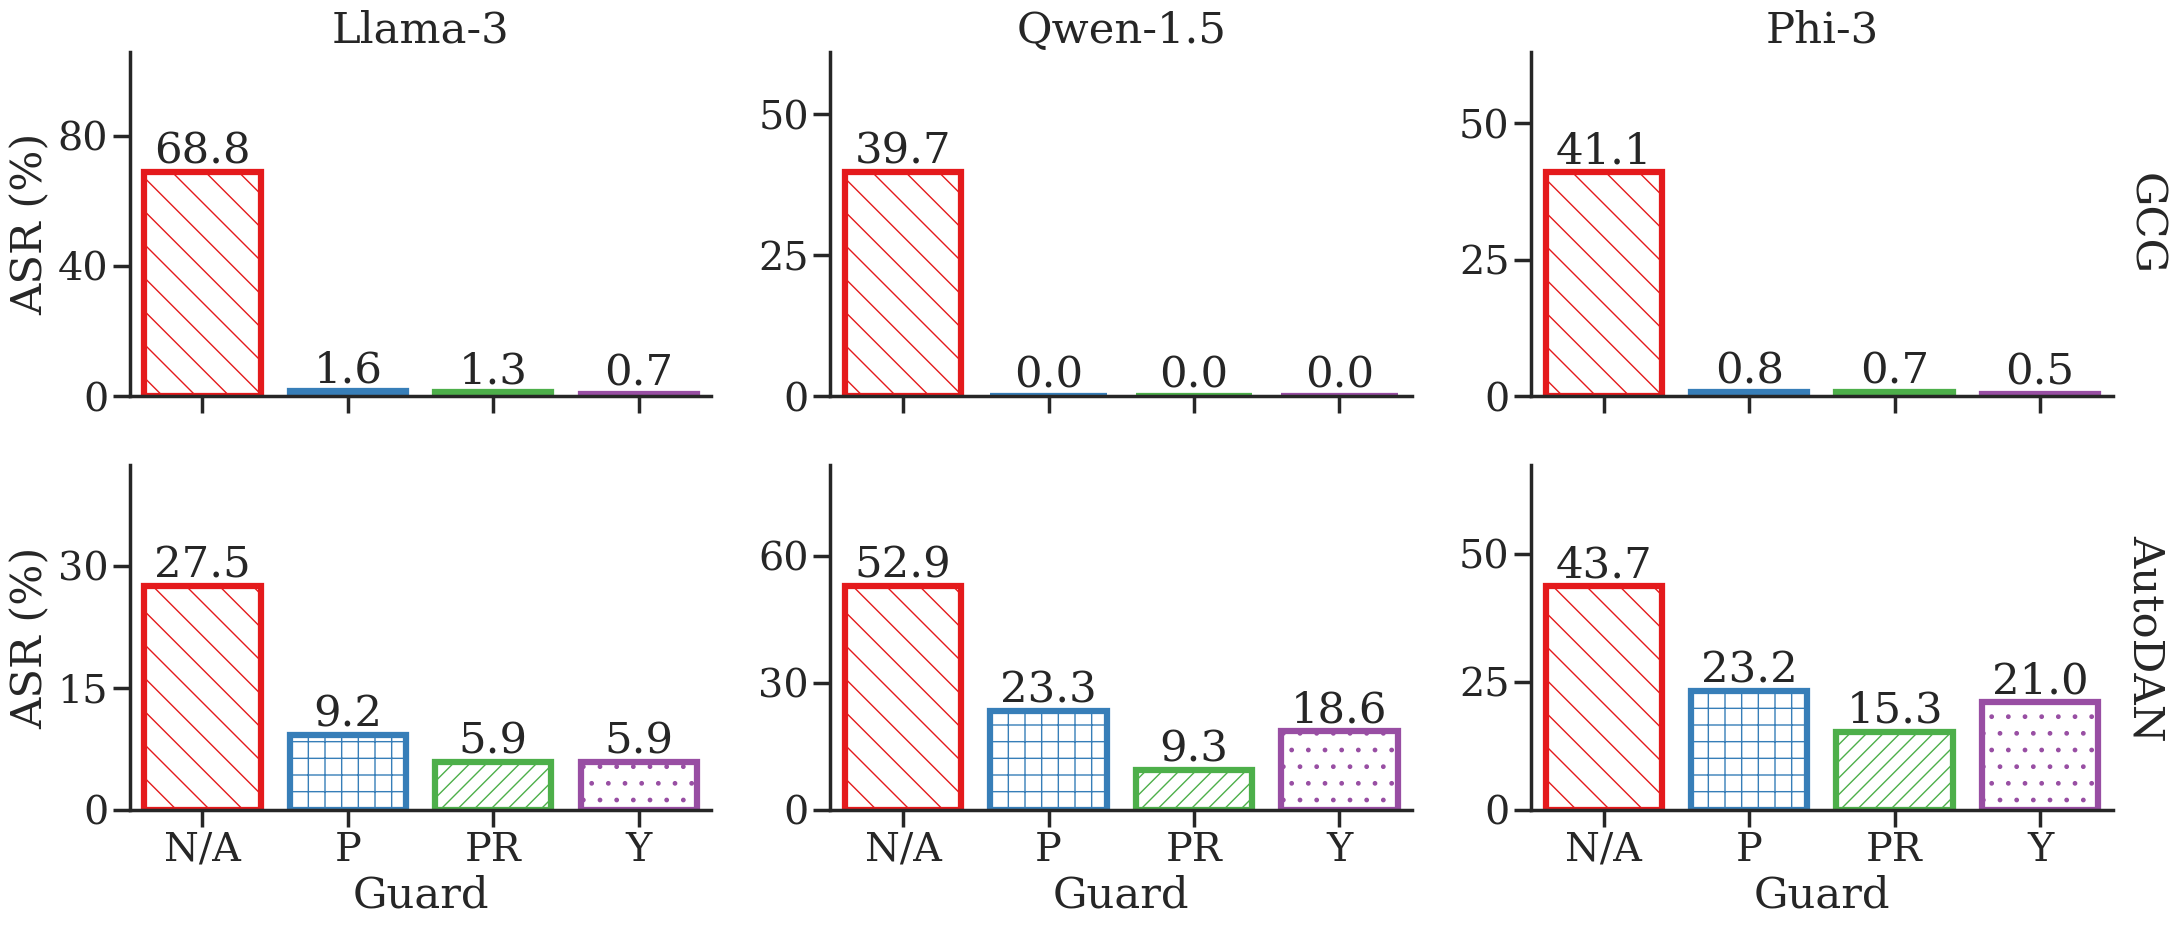

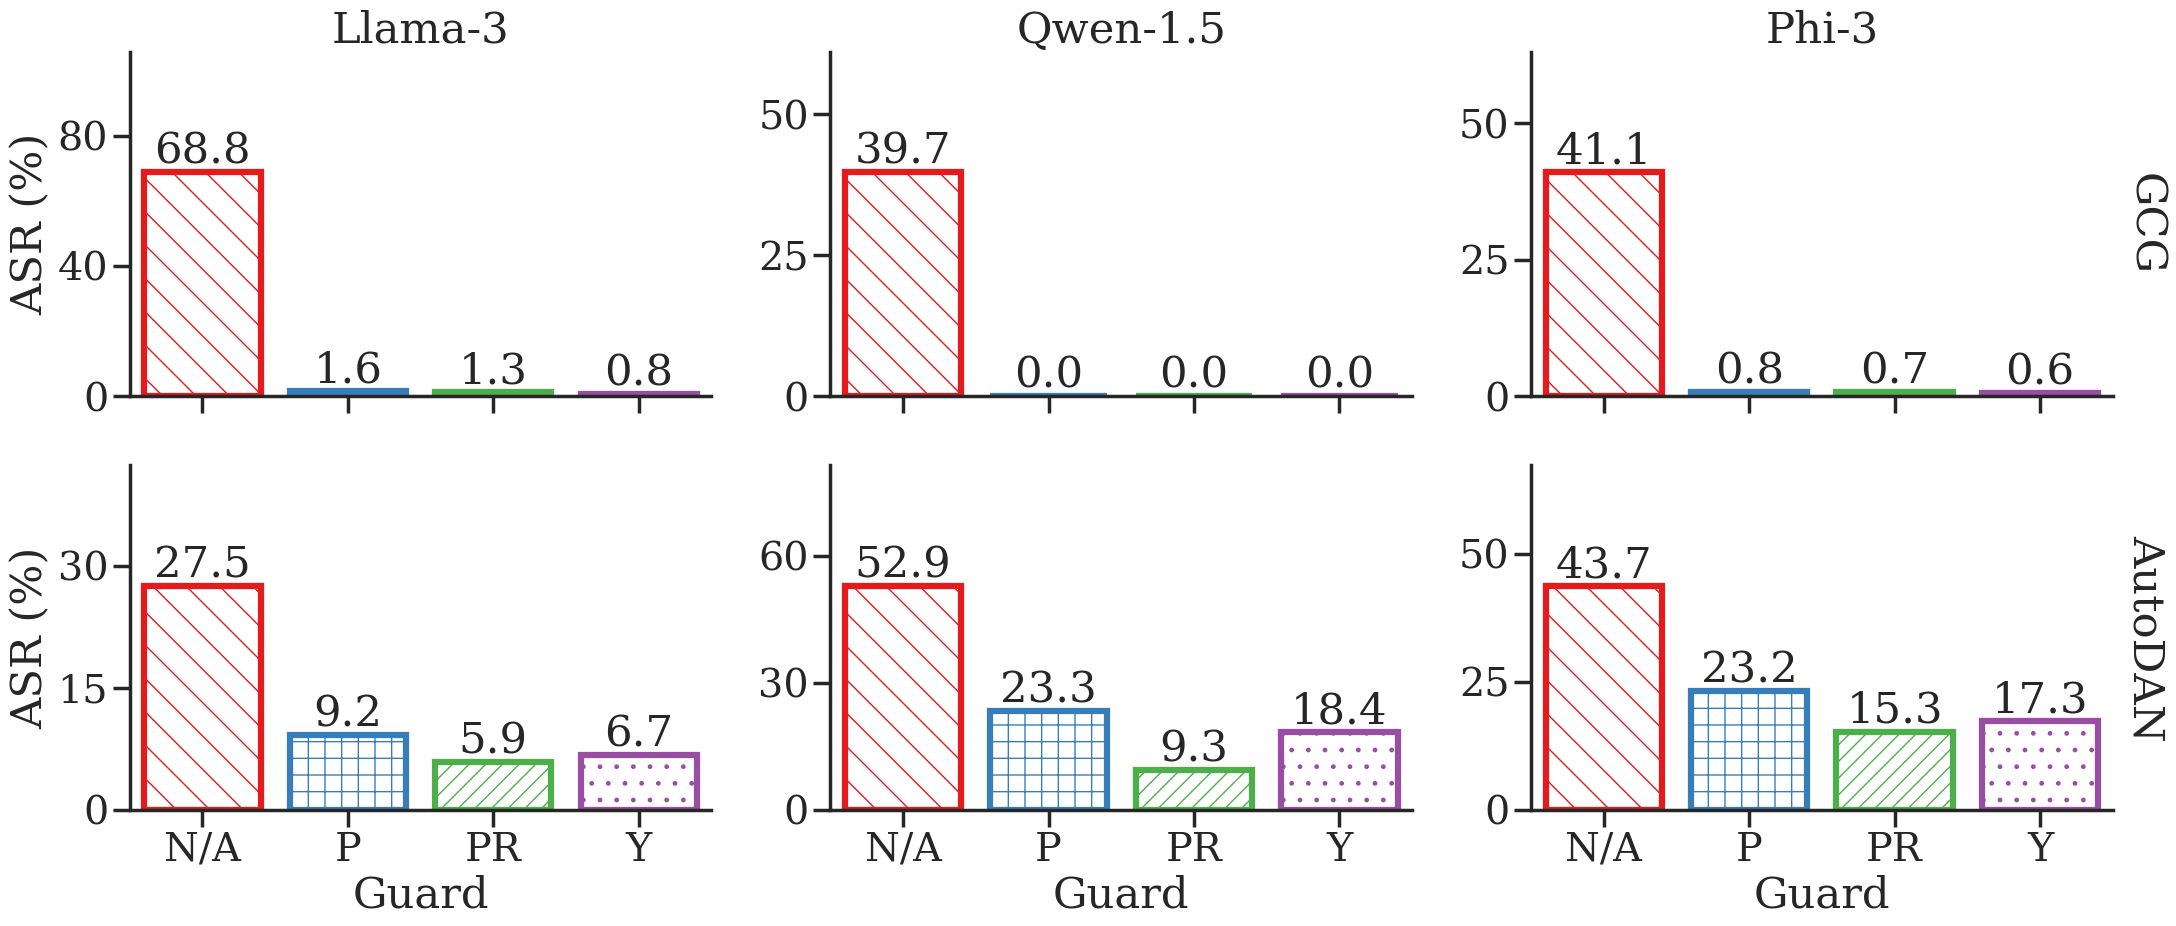

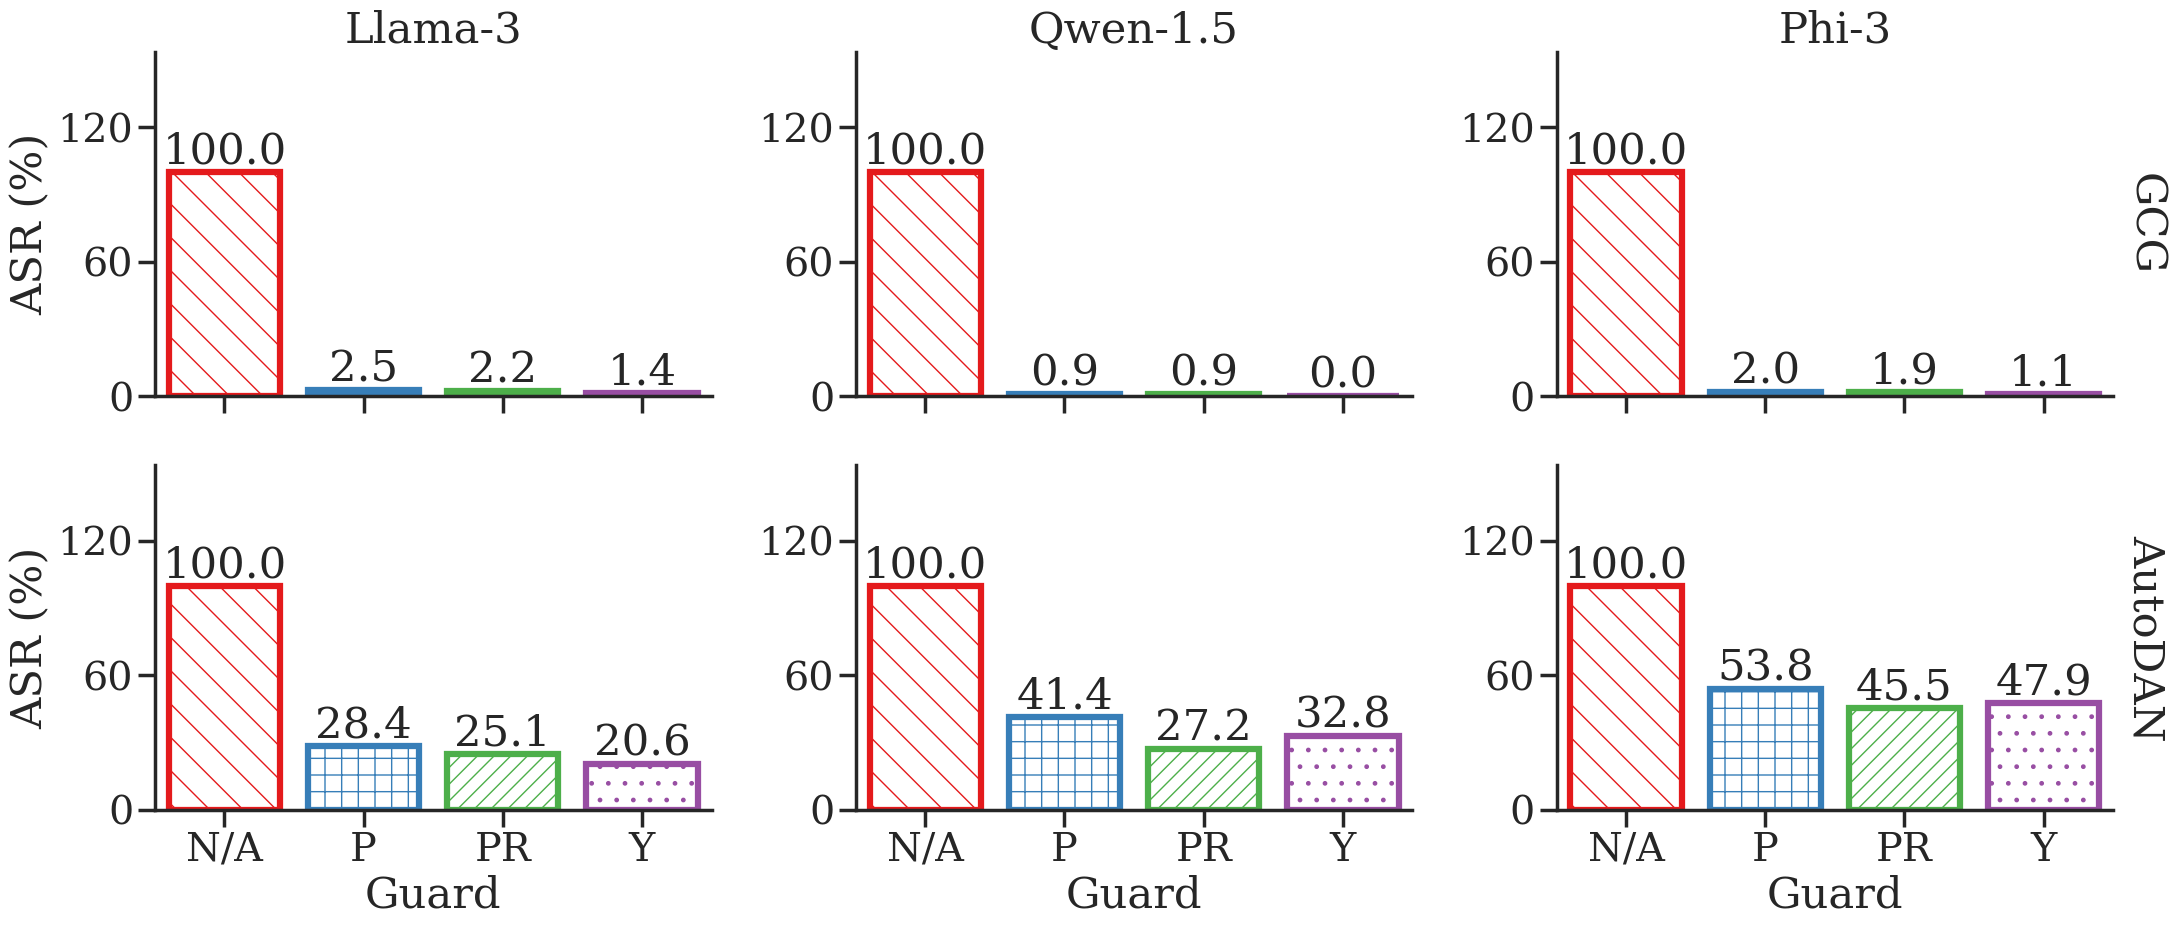

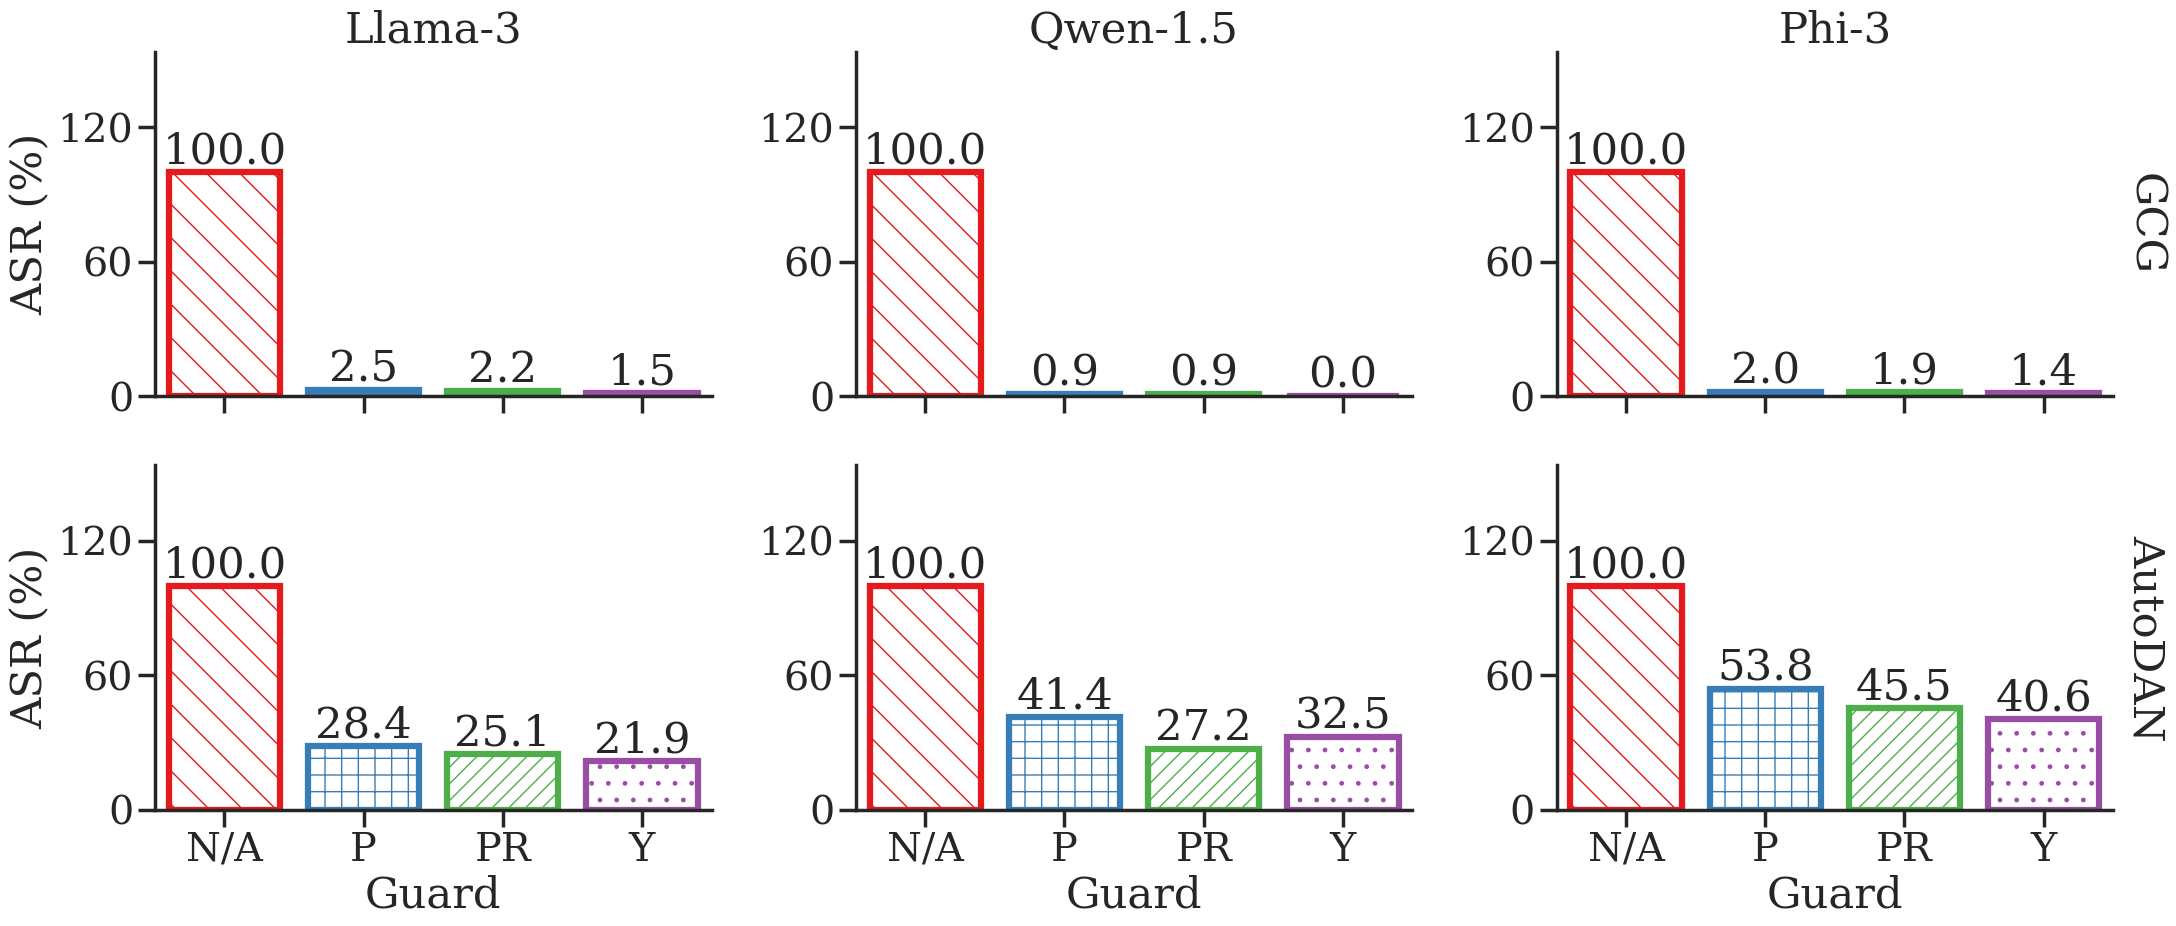

In [66]:
def plot_bar(dataframe, x, palette):
    figure = sns.catplot(
        data=dataframe,
        kind="bar",
        x=x,
        y="ASR (%)",
        row="Generation",
        col="Target Model",
        # hue=hue,
        # style=hue,
        palette=palette,
        aspect=1.5,
        fill=False,
        sharey=False,
        margin_titles=True,
    )
    # figure.set_titles("")
    figure.set_titles(row_template="{row_name}", col_template="{col_name}")

    for (target_model_alias, generation_name), ax in figure.axes_dict.items():
        for container in ax.containers:
            ax.set_ylim(top=ax.get_ylim()[1] * 1.1)
            ax.bar_label(container, fmt="%.1f", label_type="edge")
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=3))

        hatches = ["\\", "+", "//", ".", "|"]
        for bars, hatch in zip(ax.containers, hatches):
            for bar in bars:
                bar.set_hatch(hatch)
                
    # sns.move_legend(figure, "lower center", bbox_to_anchor=(0.4, 1), ncol=5)

    figure.tight_layout()

sns.set_context("poster", font_scale=1.3)

plt.clf()
for ground_truth_guard_name in ["GPT", "AllTrueGuard"]:
    for draft_model_name in ["opt-125m-AWQ", "SmolLM-135M"]:
        df = construct_dataframe_for_bar(
            dataset_name, draft_model_name, ground_truth_guard_name
        )
        df["ASR (%)"] = df["ASR"] * 100
        print(df.columns)
        plot_bar(df, "Guard", "Set1")
        plt.savefig(
            figure_dir_path
            / f"ASR_bar_{ground_truth_guard_name}_{draft_model_name}.pdf",
            bbox_inches="tight",
            transparent="True",
            pad_inches=0,
        )

In [ ]:
def draw(df, ax):
    sns.barplot(df["ASR"] * 100, fill=False, palette="Set1", ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", label_type="edge")

    # ax2 = plt.twinx()
    # sns.lineplot(data=df["average_time_for_successful_defense"], ax=ax2, marker="o")
    # ax.set_xticklabels(ax.get_xticklabels()) # rotation=45,ha="right",rotation_mode='anchor'

    ax.set_ylim(top=ax.get_ylim()[1] * 1.2)

    hatches = ["\\", "+", "//", ".", "|"]
    for bars, hatch in zip(ax.containers, hatches):
        for bar in bars:
            bar.set_hatch(hatch)

for target_model_name in [
    "Meta-Llama-3-70B-Instruct-AWQ",
    "Qwen1.5-72B-Chat-AWQ",
    "Phi-3-medium-128k-instruct",
]:
    for draft_model_name in ["opt-125m-AWQ", "SmolLM-135M"]:
        for ground_truth_guard_name in ["GPT", "AllTrueGuard"]:
            plt.clf()
            fig, axes = plt.subplots(1, 2, figsize=(12, 2.2))
            for i, generation_name in enumerate(["GCG", "AutoDAN"]):
                path = (
                    Path.cwd()
                    / "step_7_result"
                    / dataset_name
                    / target_model_name
                    / generation_name
                    / draft_model_name
                    / f"{ground_truth_guard_name}_0.1.pkl"
                )
                ax = axes[i]
                df = pd.read_pickle(path)
                df = df.loc[
                    [
                        "NA",
                        "LlamaGuardPrompt",
                        "LlamaGuardPrompt_and_LlamaGuardPromptResponse",
                        "sandbox_5",
                    ]
                ]

                df.index = ["N/A", "LG(P)", "LG(PR)", "Sandbox"]
                draw(df, ax)

                if i == 0:
                    ax.set(ylabel="ASR (%)")
                else:
                    # hide y label
                    ax.set(ylabel=None)

            plt.tight_layout()
            plt.show()

            # plt.savefig(
            #     figure_dir_path
            #     / f"bar_ASR_{dataset_name}_{target_model_name}_{generation_name}_{draft_model_name}_{ground_truth_guard_name}.pdf",
            #     bbox_inches="tight",
            #     transparent="True",
            #     pad_inches=0,
            # )

# sns.lineplot(df["average_time_for_successful_defense"])

In [ ]:
# ax = sns.barplot(df["average_time_for_successful_defense"])
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.3f', label_type='edge')

# # ax2 = plt.twinx()
# # sns.lineplot(data=df["average_time_for_successful_defense"], ax=ax2, marker="o")

# ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode='anchor')